In [28]:
# --- 1. SETUP, DOWNLOAD, AND UNZIP (Definitive Version) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import zipfile

# --- Install necessary libraries ---
!pip install -q kaggle

# --- Custom Instance Normalization Layer (Simple, Compatible Version) ---
# This version does NOT use the incompatible decorator.
# --- Custom Instance Normalization Layer (Final, Robust Version) ---
class InstanceNormalization(layers.Layer):
  # THE FIX IS HERE: We add **kwargs to the constructor
  def __init__(self, epsilon=1e-5, **kwargs):
    # And pass them up to the parent class
    super(InstanceNormalization, self).__init__(**kwargs)
    self.epsilon = epsilon

  def build(self, input_shape):
    self.scale = self.add_weight(name='scale', shape=input_shape[-1:], initializer=tf.random_normal_initializer(1., 0.02), trainable=True)
    self.offset = self.add_weight(name='offset', shape=input_shape[-1:], initializer='zeros', trainable=True)

  def call(self, x):
    mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
    inv = tf.math.rsqrt(variance + self.epsilon)
    normalized = (x - mean) * inv
    return self.scale * normalized + self.offset

  # We also add get_config for robustness with this saving method
  def get_config(self):
      config = super(InstanceNormalization, self).get_config()
      config.update({'epsilon': self.epsilon})
      return config

# Create a mock 'tfa' object for compatibility with the model-building code
# This allows the line 'tfa.layers.InstanceNormalization' to work.
class TfaMock:
    class layers:
        InstanceNormalization = InstanceNormalization
tfa = TfaMock()

# --- Kaggle and GPU Setup ---
print("TensorFlow version:", tf.__version__)
if not tf.config.list_physical_devices('GPU'):
    print("WARNING: No GPU found.")

# --- !!! ACTION REQUIRED: Replace with your Kaggle credentials !!! ---
os.environ['KAGGLE_USERNAME'] = "YOUR_KAGGLE_USERNAME"
os.environ['KAGGLE_KEY'] = "YOUR_KAGGLE_KEY"

# --- Download and Unzip (Robust Method) ---
DATA_DIR = "/content/datasets/sketches"
os.makedirs(DATA_DIR, exist_ok=True)
!kaggle datasets download -d almightyj/person-face-sketches -p {DATA_DIR}
ZIP_PATH = os.path.join(DATA_DIR, "person-face-sketches.zip")
print("\nUnzipping the dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)
print("Unzipping complete.")
os.remove(ZIP_PATH)
print("\nVerifying contents:")
!ls {DATA_DIR}/train

TensorFlow version: 2.19.0
Dataset URL: https://www.kaggle.com/datasets/almightyj/person-face-sketches
License(s): CC0-1.0
 98% 1.26G/1.29G [01:33<00:00, 43.2MB/s]
100% 1.29G/1.29G [01:34<00:00, 14.7MB/s]

Unzipping the dataset...
Unzipping complete.

Verifying contents:
photos	sketches


In [29]:
# Temporary cell to verify the final file structure
!ls /content/datasets/sketches/train/

photos	sketches


Full dataset size: 20655 image pairs.
Using 5.0% of the dataset: 1032 image pairs.

Data pipeline created successfully.


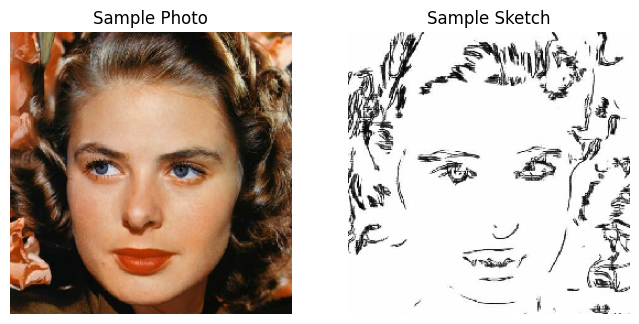

In [30]:
# --- 3. DATA PREPROCESSING AND PIPELINE (with Dataset Sub-sampling) ---

# --- !!! STRATEGIC CHANGE FOR FASTER TRAINING !!! ---
# We will only use a fraction of the dataset to make epoch times manageable.
# 25% (approx. 2500 images) is a good starting point. You can increase this later
# if you have more time, but this will allow you to complete the training.
TAKE_PERCENT = 0.05

# --- Define paths ---
PATH = os.path.join(DATA_DIR, 'train')
PHOTO_PATH = os.path.join(PATH, 'photos')
SKETCH_PATH = os.path.join(PATH, 'sketches')

# --- Define hyperparameters ---
BUFFER_SIZE = 1000
BATCH_SIZE = 1
IMG_WIDTH = 256
IMG_HEIGHT = 256

# --- Preprocessing Functions (these are correct and do not need to change) ---
def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image, channels=3)
    return image

def resize(image, height, width):
    return tf.image.resize(image, [height, width], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

def random_crop(image):
    return tf.image.random_crop(image, size=[IMG_HEIGHT, IMG_WIDTH, 3])

def random_jitter(image):
    image = resize(image, 286, 286)
    image = random_crop(image)
    image = tf.image.random_flip_left_right(image)
    return image

def normalize(image):
    image = tf.cast(image, tf.float32)
    return (image / 127.5) - 1.0

def preprocess_image_train(image_file):
    image = load_image(image_file)
    image = random_jitter(image)
    image = normalize(image)
    return image

# --- Create the tf.data.Dataset pipelines (Updated with Sub-sampling) ---

# Step 1: Create datasets of the file paths
photo_files_ds = tf.data.Dataset.list_files(PHOTO_PATH + '/*.jpg', shuffle=False)
sketch_files_ds = tf.data.Dataset.list_files(SKETCH_PATH + '/*.jpg', shuffle=False)

# --- NEW SUB-SAMPLING LOGIC ---
# Calculate how many images to take based on the percentage
try:
    num_files = tf.data.experimental.cardinality(photo_files_ds).numpy()
    if num_files == -2: # Cardinality is unknown, let's count manually
        num_files = len(list(photo_files_ds))

    num_to_take = int(num_files * TAKE_PERCENT)
    print(f"Full dataset size: {num_files} image pairs.")
    print(f"Using {TAKE_PERCENT*100}% of the dataset: {num_to_take} image pairs.")

    # Use .take() to select only the first N images
    photo_files_ds = photo_files_ds.take(num_to_take)
    sketch_files_ds = sketch_files_ds.take(num_to_take)
except Exception as e:
    print(f"Could not determine dataset size automatically. Defaulting to a fixed number. Error: {e}")
    num_to_take = 2500 # A safe default
    photo_files_ds = photo_files_ds.take(num_to_take)
    sketch_files_ds = sketch_files_ds.take(num_to_take)
# --- END OF NEW LOGIC ---

# Step 2: MAP the preprocessing function onto the smaller datasets of file paths
train_photos = photo_files_ds.map(preprocess_image_train, num_parallel_calls=tf.data.AUTOTUNE)
train_sketches = sketch_files_ds.map(preprocess_image_train, num_parallel_calls=tf.data.AUTOTUNE)

# Step 3: Zip, shuffle, and batch the final datasets
train_dataset = tf.data.Dataset.zip((train_photos, train_sketches))
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print("\nData pipeline created successfully.")

# --- Visualize a sample pair (this part is unchanged) ---
sample_photo, sample_sketch = next(iter(train_dataset))
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.title("Sample Photo")
plt.imshow(sample_photo[0] * 0.5 + 0.5)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sample Sketch")
plt.imshow(sample_sketch[0] * 0.5 + 0.5)
plt.axis("off")

plt.show()

In [31]:
# --- 4. BUILD THE GENERATOR AND DISCRIMINATOR MODELS ---

OUTPUT_CHANNELS = 3

# --- Generator Building Blocks ---
# The Generator is a modified U-Net. We define the downsampling (encoder)
# and upsampling (decoder) blocks first.

def downsample(filters, size, apply_instancenorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_instancenorm:
        result.add(tfa.layers.InstanceNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                     kernel_initializer=initializer, use_bias=False))
    result.add(tfa.layers.InstanceNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

# --- Generator Model (U-Net) ---
def build_generator():
    inputs = layers.Input(shape=[256, 256, 3])

    # Encoder (downsampling)
    down_stack = [
        downsample(64, 4, apply_instancenorm=False), # (bs, 128, 128, 64)
        downsample(128, 4), # (bs, 64, 64, 128)
        downsample(256, 4), # (bs, 32, 32, 256)
        downsample(512, 4), # (bs, 16, 16, 512)
        downsample(512, 4), # (bs, 8, 8, 512)
        downsample(512, 4), # (bs, 4, 4, 512)
        downsample(512, 4), # (bs, 2, 2, 512)
        downsample(512, 4), # (bs, 1, 1, 512)
    ]

    # Decoder (upsampling)
    up_stack = [
        upsample(512, 4, apply_dropout=True), # (bs, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 8, 8, 1024)
        upsample(512, 4), # (bs, 16, 16, 1024)
        upsample(256, 4), # (bs, 32, 32, 512)
        upsample(128, 4), # (bs, 64, 64, 256)
        upsample(64, 4),  # (bs, 128, 128, 128)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(OUTPUT_CHANNELS, 4, strides=2, padding='same',
                                  kernel_initializer=initializer, activation='tanh') # (bs, 256, 256, 3)

    x = inputs

    # Build the U-Net with skip connections
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)

    return keras.Model(inputs=inputs, outputs=x)


# --- Discriminator Model (PatchGAN) ---
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    inp = layers.Input(shape=[256, 256, 3], name='input_image')

    # PatchGAN architecture
    x = downsample(64, 4, False)(inp) # (bs, 128, 128, 64)
    x = downsample(128, 4)(x) # (bs, 64, 64, 128)
    x = downsample(256, 4)(x) # (bs, 32, 32, 256)

    zero_pad1 = layers.ZeroPadding2D()(x) # (bs, 34, 34, 256)
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1) # (bs, 31, 31, 512)
    norm1 = tfa.layers.InstanceNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(norm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu) # (bs, 33, 33, 512)
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2) # (bs, 30, 30, 1)

    return tf.keras.Model(inputs=inp, outputs=last)


# --- Create the four models ---
generator_g = build_generator() # Translates Photo -> Sketch
generator_f = build_generator() # Translates Sketch -> Photo

discriminator_x = build_discriminator() # Judges Photos
discriminator_y = build_discriminator() # Judges Sketches

print("All four models (2 Generators, 2 Discriminators) built successfully.")

# Let's visualize one of the generators
print("\nGenerator Architecture:")
generator_g.summary()

All four models (2 Generators, 2 Discriminators) built successfully.

Generator Architecture:


Model: "functional_181"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_152     │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_144      │ (None, 128, 128,  │      3,072 │ input_layer_152[… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_145      │ (None, 64, 64,    │    131,328 │ sequential_144[0… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_146      │ (None, 32, 32,    │    524,800 │ sequential_145[0… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_147      │ (None, 16, 16,    │  2,098,176 │ sequential_146[0… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_148      │ (None, 8, 8, 512) │  4,195,328 │ sequential_147[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_149      │ (None, 4, 4, 512) │  4,195,328 │ sequential_148[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_150      │ (None, 2, 2, 512) │  4,195,328 │ sequential_149[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_151      │ (None, 1, 1, 512) │  4,195,328 │ sequential_150[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_152      │ (None, 2, 2, 512) │  4,195,328 │ sequential_151[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_56      │ (None, 2, 2,      │          0 │ sequential_152[0… │
│ (Concatenate)       │ 1024)             │            │ sequential_150[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_153      │ (None, 4, 4, 512) │  8,389,632 │ concatenate_56[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_57      │ (None, 4, 4,      │          0 │ sequential_153[0… │
│ (Concatenate)       │ 1024)             │            │ sequential_149[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_154      │ (None, 8, 8, 512) │  8,389,632 │ concatenate_57[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_58      │ (None, 8, 8,      │          0 │ sequential_154[0… │
│ (Concatenate)       │ 1024)             │            │ sequential_148[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_155      │ (None, 16, 16,    │  8,389,632 │ concatenate_58[0… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_59      │ (None, 16, 16,    │          0 │ sequential_155[0

 Total params: 54,414,979 (207.58 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# --- 5. DEFINE LOSS FUNCTIONS AND OPTIMIZERS ---

# We use Binary Cross-Entropy for the adversarial loss
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# --- Discriminator Loss ---
# The discriminator's job is to correctly classify real and fake images.
def discriminator_loss(real, generated):
    real_loss = loss_obj(tf.ones_like(real), real) # Real images should be classified as 1
    generated_loss = loss_obj(tf.zeros_like(generated), generated) # Fake images as 0
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss * 0.5

# --- Generator Loss ---
# The generator's job is to fool the discriminator.
def generator_loss(generated):
    # It wins if the discriminator classifies its fake images as 1 (real).
    return loss_obj(tf.ones_like(generated), generated)

# --- Cycle-Consistency Loss ---
# This is the L1 distance between the original image and the cycled image.
# We want this distance to be as small as possible.
def calc_cycle_loss(real_image, cycled_image):
    loss1 = tf.reduce_mean(tf.abs(real_image - cycled_image))
    return LAMBDA * loss1 # LAMBDA is a weight for this loss, typically 10

# --- Identity Loss ---
def identity_loss(real_image, same_image):
    loss = tf.reduce_mean(tf.abs(real_image - same_image))
    return LAMBDA * 0.5 * loss

# --- Optimizers ---
# We need separate optimizers for each of our four models.
generator_g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator_x_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# Hyperparameter for the cycle and identity losses
LAMBDA = 10

print("Loss functions and optimizers defined successfully.")

Loss functions and optimizers defined successfully.


In [33]:
# --- 6. CHECKPOINTING AND CUSTOM TRAINING STEP ---

# --- Checkpoint Manager Setup ---
# Define the directory where checkpoints will be saved
checkpoint_path = "./checkpoints/train"

# Create a Checkpoint object that tracks all the components we need to save:
# the two generators, the two discriminators, and their four optimizers.
ckpt = tf.train.Checkpoint(generator_g=generator_g,
                           generator_f=generator_f,
                           discriminator_x=discriminator_x,
                           discriminator_y=discriminator_y,
                           generator_g_optimizer=generator_g_optimizer,
                           generator_f_optimizer=generator_f_optimizer,
                           discriminator_x_optimizer=discriminator_x_optimizer,
                           discriminator_y_optimizer=discriminator_y_optimizer)

# The CheckpointManager handles saving and loading multiple checkpoints.
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# --- The Custom Training Step ---
# We use the @tf.function decorator to compile this function into a high-performance
# TensorFlow graph. This makes training much faster.
@tf.function
def train_step(real_x, real_y):
    # real_x is a real photo, real_y is a real sketch

    # We use GradientTape to record all operations for automatic differentiation.
    with tf.GradientTape(persistent=True) as tape:
        # --- Forward Pass ---
        # 1. Generate fake images
        fake_y = generator_g(real_x, training=True) # Fake sketch from real photo
        cycled_x = generator_f(fake_y, training=True) # Cycled photo from fake sketch

        fake_x = generator_f(real_y, training=True) # Fake photo from real sketch
        cycled_y = generator_g(fake_x, training=True) # Cycled sketch from fake photo

        # 2. Generate identity images (for identity loss)
        same_x = generator_f(real_x, training=True)
        same_y = generator_g(real_y, training=True)

        # 3. Get discriminator outputs
        disc_real_x = discriminator_x(real_x, training=True)
        disc_real_y = discriminator_y(real_y, training=True)

        disc_fake_x = discriminator_x(fake_x, training=True)
        disc_fake_y = discriminator_y(fake_y, training=True)

        # --- Calculate all Losses ---
        # 4. Generator adversarial losses
        gen_g_loss = generator_loss(disc_fake_y)
        gen_f_loss = generator_loss(disc_fake_x)

        # 5. Cycle-consistency losses
        total_cycle_loss = calc_cycle_loss(real_x, cycled_x) + calc_cycle_loss(real_y, cycled_y)

        # 6. Identity losses
        total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
        total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

        # 7. Discriminator losses
        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    # --- Calculate and Apply Gradients ---
    # 8. Get the gradients from the tape
    generator_g_gradients = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
    generator_f_gradients = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

    discriminator_x_gradients = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
    discriminator_y_gradients = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

    # 9. Apply the gradients to the optimizers to update the model weights
    generator_g_optimizer.apply_gradients(zip(generator_g_gradients, generator_g.trainable_variables))
    generator_f_optimizer.apply_gradients(zip(generator_f_gradients, generator_f.trainable_variables))

    discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients, discriminator_x.trainable_variables))
    discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients, discriminator_y.trainable_variables))

    # Return the losses for monitoring
    return total_gen_g_loss, total_gen_f_loss, disc_x_loss, disc_y_loss

print("Checkpoint manager and custom train_step function defined successfully.")

Checkpoint manager and custom train_step function defined successfully.


In [34]:
# --- 7. THE MAIN TRAINING LOOP (Corrected and Final) ---
from IPython.display import clear_output

# --- Attempt to restore from the latest checkpoint ---
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    print(f'Latest checkpoint restored!! Resuming training from epoch {start_epoch + 1}.')
else:
    start_epoch = 0
    print("No checkpoint found. Starting training from scratch.")

# --- Helper function to generate and save test images ---
def generate_images(model, test_input):
    prediction = model(test_input)
    plt.figure(figsize=(12, 12))
    display_list = [test_input[0], prediction[0]]
    title = ['Input Image', 'Predicted Image']
    for i in range(2):
        plt.subplot(1, 2, i+1)
        plt.title(title[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

# --- The Loop ---
EPOCHS = 20

for epoch in range(start_epoch, EPOCHS):
    start = time.time()

    print(f"--- Epoch {epoch + 1}/{EPOCHS} ---")

    n = 0
    for (real_photo, real_sketch) in train_dataset:
        gen_g_loss, gen_f_loss, disc_x_loss, disc_y_loss = train_step(real_photo, real_sketch)
        if n % 200 == 0:
            # Print a dot every 200 steps to show progress
            print('.', end='')
        n += 1

    # Use clear_output to keep the notebook clean
    clear_output(wait=True)

    # Generate and display a sample translation to monitor progress
    print("Generating sample translation for epoch:", epoch + 1)
    generate_images(generator_g, sample_photo) # Use the sample_photo from our data pipeline cell

    # --- Save a checkpoint at the end of EVERY epoch ---
    ckpt_save_path = ckpt_manager.save()
    print(f'Saving checkpoint for epoch {epoch+1} at {ckpt_save_path}')
    print(f'Time taken for 1 epoch: {time.time()-start:.2f} sec')
    # Print the losses for monitoring
    print(f'Generator G Loss: {gen_g_loss:.4f}, Generator F Loss: {gen_f_loss:.4f}')
    print(f'Discriminator X Loss: {disc_x_loss:.4f}, Discriminator Y Loss: {disc_y_loss:.4f}')

Latest checkpoint restored!! Resuming training from epoch 21.


Restoring latest checkpoint for inference...
Checkpoint restored.

--- Translating Photo to Sketch ---


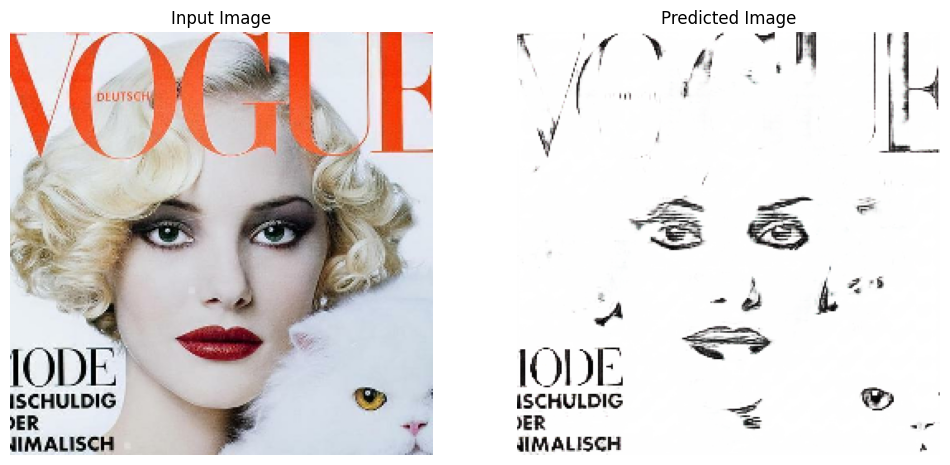


--- Translating Sketch to Photo ---


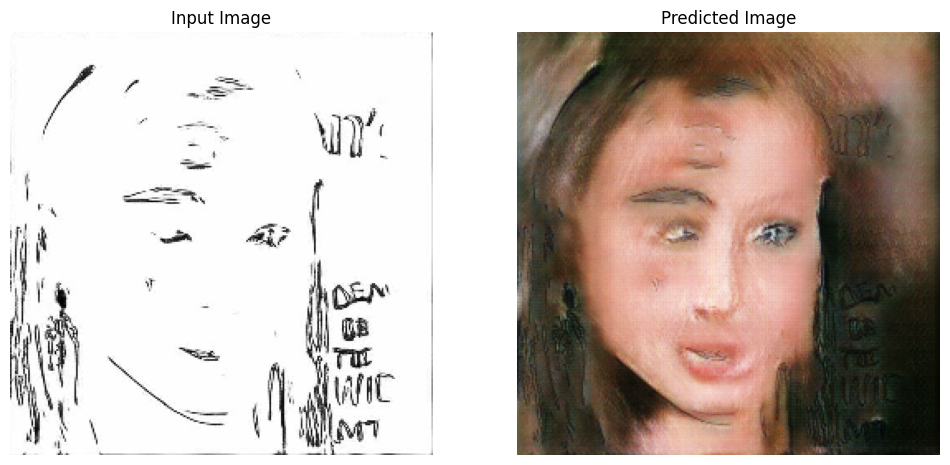

In [35]:
# --- 8. FINAL INFERENCE AND DEMONSTRATION ---

# The checkpoint manager automatically tracks the latest checkpoint.
# We will restore it to make sure we are using our fully trained models.
print("Restoring latest checkpoint for inference...")
ckpt.restore(ckpt_manager.latest_checkpoint)
print("Checkpoint restored.")

# --- Define a new data pipeline for the TEST set ---
# This pipeline is simpler: no shuffling, no jittering. Just resize and normalize.
def preprocess_image_test(image_file):
    image = load_image(image_file)
    image = resize(image, IMG_HEIGHT, IMG_WIDTH)
    image = normalize(image)
    return image

# Create datasets for the test images
test_photo_ds = tf.data.Dataset.list_files(os.path.join(DATA_DIR, 'test/photos/*.jpg')).map(preprocess_image_test).batch(1)
test_sketch_ds = tf.data.Dataset.list_files(os.path.join(DATA_DIR, 'test/sketches/*.jpg')).map(preprocess_image_test).batch(1)

# --- Demonstrate Photo -> Sketch Translation ---
print("\n--- Translating Photo to Sketch ---")
# Get a sample photo from the test set
for inp in test_photo_ds.take(1):
    generate_images(generator_g, inp)

# --- Demonstrate Sketch -> Photo Translation ---
print("\n--- Translating Sketch to Photo ---")
# Get a sample sketch from the test set
for inp in test_sketch_ds.take(1):
    # Here we use the OTHER generator: generator_f
    generate_images(generator_f, inp)

Saving generators for the web app...
Generators saved.

--- Testing UI logic with a sample photo ---
Mean Saturation: 82.75
Input detected as a PHOTO. Translating to Sketch.


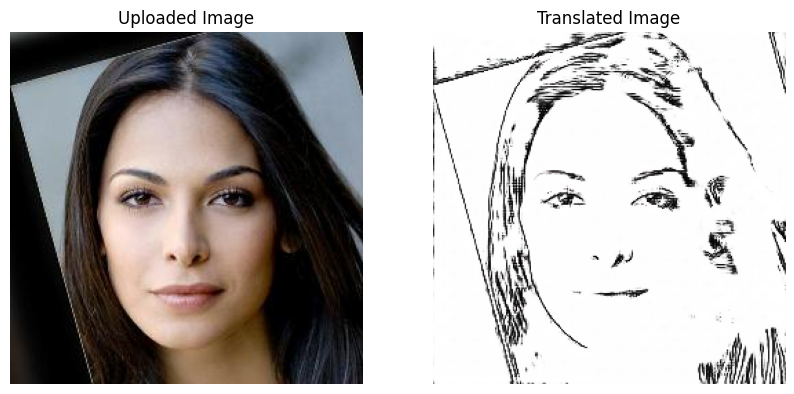

In [36]:
# --- 9. PROTOTYPING THE FLASK UI LOGIC (Corrected for Custom Objects) ---

# First, save the generators. This will now work correctly.
print("Saving generators for the web app...")
generator_g.save('photo_to_sketch_generator.keras')
generator_f.save('sketch_to_photo_generator.keras')
print("Generators saved.")

# --- THE FIX: Define our custom object for the loader ---
# This dictionary tells Keras what 'InstanceNormalization' means when it's loading.
custom_objects = {'InstanceNormalization': InstanceNormalization}


# Now, let's define the function that will be the heart of our Flask app.
from PIL import Image
import io

def translate_image_logic(image_bytes):
    pil_image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

    hsv_image = pil_image.convert('HSV')
    saturation_channel = np.array(hsv_image)[:, :, 1]
    mean_saturation = np.mean(saturation_channel)

    print(f"Mean Saturation: {mean_saturation:.2f}")

    image = tf.convert_to_tensor(np.array(pil_image))
    image = resize(image, IMG_HEIGHT, IMG_WIDTH) # Assumes resize() is defined in a previous cell
    image = normalize(image) # Assumes normalize() is defined in a previous cell
    image = tf.expand_dims(image, 0)

    if mean_saturation < 25:
        print("Input detected as a SKETCH. Translating to Photo.")
        # Pass the custom_objects dictionary during loading
        translator_model = keras.models.load_model('sketch_to_photo_generator.keras', custom_objects=custom_objects)
    else:
        print("Input detected as a PHOTO. Translating to Sketch.")
        # Pass the custom_objects dictionary during loading
        translator_model = keras.models.load_model('photo_to_sketch_generator.keras', custom_objects=custom_objects)

    prediction = translator_model(image, training=False)[0]
    prediction_denorm = (prediction * 0.5 + 0.5).numpy()

    return pil_image, Image.fromarray((prediction_denorm * 255).astype(np.uint8))


# --- Let's test the logic with a sample photo ---
print("\n--- Testing UI logic with a sample photo ---")
# Assumes 'test_photo_ds' is defined in a previous cell
for inp in test_photo_ds.take(1):
    pil_img = Image.fromarray((inp[0].numpy() * 127.5 + 127.5).astype(np.uint8))
    img_byte_arr = io.BytesIO()
    pil_img.save(img_byte_arr, format='JPEG')
    img_byte_arr = img_byte_arr.getvalue()

    input_img, output_img = translate_image_logic(img_byte_arr)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.title("Uploaded Image"); plt.imshow(input_img); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title("Translated Image"); plt.imshow(output_img); plt.axis('off')
    plt.show()